<a href="https://colab.research.google.com/github/sophia-grothe/PracticumAI-deep_learning/blob/yolov8/SG_Project_DeepLearning_YOLOv8_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/'

In [ ]:
import os
import random
import shutil

# Initialize train, validation, and test lists
train = []
val = []
test = []

# Define the classes to keep (0 to 4 for a total of 5 classes)
valid_classes = {0, 1, 2, 3, 4}

# Function to create a directory if it doesn't exist
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

# Function to read the label files and load images
def read_label_files(folder_name):
    '''
    folder_name: name of the folder we are targeting (e.g., 'train', 'valid')
    '''
    # Define paths to images and labels within the folder
    image_folder = os.path.join(base_path, folder_name, 'images')  # Expect 'images' subfolder
    label_folder = os.path.join(base_path, folder_name, 'labels')  # Expect 'labels' subfolder

    images = []
    labels = []

    # Track missing data
    missing_labels = []
    missing_images = []

    # Iterate through image files and find corresponding labels
    for image_file in os.listdir(image_folder):
        if image_file.endswith(('.jpg', '.png', '.jpeg')):
            image_path = os.path.join(image_folder, image_file)
            label_file = os.path.splitext(image_file)[0] + ".txt"
            label_path = os.path.join(label_folder, label_file)

            if os.path.exists(label_path):
                images.append(image_path)
                # Assuming labels are in the format 'class_id x_center y_center width height'
                with open(label_path, "r") as f:
                    for line in f:
                        label_data = line.strip().split()
                        class_id = int(label_data[0])
                        if class_id in valid_classes:  # Only add labels in valid_classes
                            labels.append(class_id)
            else:
                missing_labels.append(image_file)  # Log missing label for this image

    # Track images with no corresponding label files
    for label_file in os.listdir(label_folder):
        if label_file.endswith('.txt'):
            image_file = os.path.splitext(label_file)[0] + '.jpg'  # Assuming .jpg image files
            image_path = os.path.join(image_folder, image_file)
            if not os.path.exists(image_path):
                missing_images.append(label_file)  # Log missing image for this label

    # Print missing data for further investigation
    if missing_labels:
        print(f"Warning: The following images are missing labels: {missing_labels}")
    if missing_images:
        print(f"Warning: The following labels are missing corresponding images: {missing_images}")

    return list(zip(images, labels))

# Function to save data to a specific folder
def save_data(data, folder_name):
    '''
    Args:
        data (list): A list of (image_path, label) tuples.
        folder_name (str): The target folder name ('valid' or 'test').
    '''
    image_folder = os.path.join(base_path, folder_name, 'images')
    label_folder = os.path.join(base_path, folder_name, 'labels')

    # Create directories if they don't exist
    create_dir(image_folder)
    create_dir(label_folder)

    for image_path, _ in data:
        # Copy image only if it doesn't already exist in the target folder
        image_file = os.path.basename(image_path)
        target_image_path = os.path.join(image_folder, image_file)
        if not os.path.exists(target_image_path):  # Check if the file exists before copying
            shutil.copy(image_path, target_image_path)

        # Copy label only if it doesn't already exist in the target folder
        label_file = os.path.splitext(image_file)[0] + ".txt"
        source_label_path = os.path.join(os.path.dirname(image_path).replace("images", "labels"), label_file)
        target_label_path = os.path.join(label_folder, label_file)

        if os.path.exists(source_label_path) and not os.path.exists(target_label_path):  # Check if the file exists before copying
            shutil.copy(source_label_path, target_label_path)

# Assuming you have 'train' and 'valid' folders directly under base_path
for folder in ['train', 'valid']:  # Iterate through your actual folders
    if folder == 'train':
        train.extend(read_label_files(folder))
    elif folder == 'valid':
        val.extend(read_label_files(folder))

# Split validation into new validation and test sets
def split_validation(val, test_ratio=0.5):
    '''
    Splits the validation set into a new validation set and test set.

    Args:
        val (list): The original validation dataset.
        test_ratio (float): The fraction of data to use for the test set.

    Returns:
        tuple: A tuple containing the new validation set and the test set.
    '''
    random.seed(42)  # Set a seed for reproducibility
    random.shuffle(val)  # Shuffle the validation data
    split_idx = int(len(val) * (1 - test_ratio))
    new_val = val[:split_idx]
    new_test = val[split_idx:]
    return new_val, new_test

# Perform the split
val, test = split_validation(val, test_ratio=0.5)

# Save the new validation and test data
save_data(val, 'valid')
save_data(test, 'test')

# Output the results
print(f"Train set: {len(train)} images")
print(f"Validation set: {len(val)} images")
print(f"Test set: {len(test)} images")



Train set: 60 images
Validation set: 30 images
Test set: 30 images


##Classification datasets

In [ ]:
import os
import random
import shutil
import yaml
from PIL import Image

# Define base path
# base_path = "/path/to/your/dataset"

# Define the classes to keep (0 to 4 for a total of 5 classes)
valid_classes = {0, 1, 2, 3, 4}

# Define the target image size
image_size = (224, 224)

# Function to create a directory if it doesn't exist
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

# Function to resize an image to the target size
def resize_image(image_path, output_path, size):
    with Image.open(image_path) as img:
        resized_img = img.resize(size)
        resized_img.save(output_path)

# Function to read label files and assign a single class to each image
def read_label_files_for_classification(folder_name):
    '''
    folder_name: name of the folder we are targeting (e.g., 'train', 'valid')
    '''
    image_folder = os.path.join(base_path, folder_name, 'images')
    label_folder = os.path.join(base_path, folder_name, 'labels')

    classification_data = []  # List to store (image_path, class_id)

    for image_file in os.listdir(image_folder):
        if image_file.endswith(('.jpg', '.png', '.jpeg')):
            image_path = os.path.join(image_folder, image_file)
            label_file = os.path.splitext(image_file)[0] + ".txt"
            label_path = os.path.join(label_folder, label_file)

            if os.path.exists(label_path):
                with open(label_path, "r") as f:
                    class_ids = set(int(line.split()[0]) for line in f if int(line.split()[0]) in valid_classes)

                    if len(class_ids) == 1:  # Only one class is present
                        classification_data.append((image_path, list(class_ids)[0]))
                    elif len(class_ids) > 1:  # Multiple classes
                        classification_data.append((image_path, random.choice(list(class_ids))))  # Pick one randomly

    return classification_data

# Function to save classification data (images and labels) to directories
def save_classification_data(data, folder_name):
    '''
    Args:
        data (list): A list of (image_path, class_id) tuples.
        folder_name (str): The target folder name ('train', 'valid', or 'test').
    '''
    base_classification_path = os.path.join(base_path, "classification_dataset", folder_name)

    for image_path, class_id in data:
        class_folder = os.path.join(base_classification_path, f"class_{class_id}")
        create_dir(class_folder)

        image_file = os.path.basename(image_path)
        target_image_path = os.path.join(class_folder, image_file)

        if not os.path.exists(target_image_path):  # Avoid duplicates
            resize_image(image_path, target_image_path, image_size)  # Resize and save the image

# Function to write the classification YAML file
def write_classification_yaml(data, folder_name, yaml_file_name):
    '''
    Args:
        data (list): A list of (image_path, class_id) tuples.
        folder_name (str): The folder for which to write the YAML ('train', 'valid', 'test').
        yaml_file_name (str): The name of the YAML file to write.
    '''
    # Prepare data in YAML format
    yaml_data = {
        'images': [],
        'labels': []
    }

    for image_path, class_id in data:
        yaml_data['images'].append(image_path)
        yaml_data['labels'].append(class_id)

    # Define the path to save the YAML file
    yaml_file_path = os.path.join(base_path, f"{folder_name}_{yaml_file_name}.yaml")

    with open(yaml_file_path, 'w') as yaml_file:
        yaml.dump(yaml_data, yaml_file)

    print(f"YAML file for {folder_name} saved as {yaml_file_path}")

# Load the train and validation datasets
train = read_label_files_for_classification('train')
val = read_label_files_for_classification('valid')

# Split validation into new validation and test sets
def split_validation(val, test_ratio=0.5):
    random.seed(42)  # Set a seed for reproducibility
    random.shuffle(val)
    split_idx = int(len(val) * (1 - test_ratio))
    new_val = val[:split_idx]
    new_test = val[split_idx:]
    return new_val, new_test

val, test = split_validation(val, test_ratio=0.5)

# Save classification datasets
save_classification_data(train, 'train')
save_classification_data(val, 'valid')
save_classification_data(test, 'test')

# Write the YAML files for each dataset (train, valid, and test)
write_classification_yaml(train, 'class', 'train_dataset')
write_classification_yaml(val, 'class', 'val_dataset')
write_classification_yaml(test, 'class', 'test_dataset')

# Output dataset statistics
print(f"Train set: {len(train)} images")
print(f"Validation set: {len(val)} images")
print(f"Test set: {len(test)} images")




YAML file for class saved as /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_train_dataset.yaml
YAML file for class saved as /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_val_dataset.yaml
YAML file for class saved as /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_test_dataset.yaml
Train set: 60 images
Validation set: 30 images
Test set: 30 images


In [ ]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.7/898.7 kB 13.5 MB/s eta 0:00:00


##Object Detection Model

In [ ]:
from ultralytics import YOLO

# Load the YOLOv8 model (pre-trained or custom architecture)
model = YOLO("yolov8n.pt")  # Use 'yolov8n.yaml' if you're training from scratch

# Train the model
model.train(data="/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/data.yaml", epochs=50, imgsz=640)

print("Training complete!")

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, s

train: Scanning /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/train/labels... 60 images, 0 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<00:00, 73.14it/s]


train: New cache created: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.22 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
val: Scanning /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/valid/labels... 60 images, 0 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<00:00, 67.35it/s]

val: New cache created: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/valid/labels.cache


...

      50/50         0G     0.4437      0.667     0.7911        239        640: 100%|██████████| 4/4 [01:03<00:00, 15.81s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:33<00:00, 16.65s/it]

                   all         60       1143       0.85      0.726      0.798        0.7



50 epochs completed in 1.252 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 6.2MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:20<00:00, 10.47s/it]


                   all         60       1143      0.871      0.735      0.833      0.722
                 Durum         12        210      0.893      0.914       0.95        0.8
                   HRS         12        213      0.959          1      0.993      0.874
                   HRW         12        240          1     0.0522      0.449      0.387
               S White         12        240      0.886      0.716      0.901      0.784
                   SRW         12        240      0.617      0.992      0.872      0.764
Speed: 6.7ms preprocess, 291.9ms inference, 0.0ms loss, 15.0ms postprocess per image
Results saved to runs/detect/train2
Training complete!


In [ ]:
metrics = model.val()  # Run validation on the test dataset
print(metrics)

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/valid/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:21<00:00,  5.36s/it]


                   all         60       1143      0.871      0.735      0.833      0.722
                 Durum         12        210      0.893      0.914       0.95        0.8
                   HRS         12        213      0.959          1      0.993      0.874
                   HRW         12        240          1     0.0522      0.449      0.387
               S White         12        240      0.886      0.716      0.901      0.784
                   SRW         12        240      0.617      0.992      0.872      0.764
Speed: 5.7ms preprocess, 305.3ms inference, 0.0ms loss, 13.3ms postprocess per image
Results saved to runs/detect/train22
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d4a05e3bb20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_r

In [ ]:
# Evaluate the model on the test set
#metrics = model.val(data="dataset.yaml")  # You can specify the path to your dataset YAML

#Print out the evaluation results
print(f"Results on test set:")
#print(f"Recall: {metrics.box.rec.mean()}")  # Access recall using .box.rec.mean() which is now metrics.box.r.mean()
print(f"Precision: {metrics.box.p.mean()}")  # Access precision using .box.p.mean()
print(f"F1 Score: {metrics.box.f1.mean()}")  # Access F1 score using .box.f1.mean()
# Access accuracy using metrics.box.map  (map refers to mAP - mean Average Precision)
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Results on test set:
Precision: 0.8710435570906766
F1 Score: 0.7068560848916141
mAP50: 0.8328497194751854
mAP50-95: 0.7219597364802641


In [ ]:
pip install ruamel.yaml

##Classifcation model

In [ ]:
import os

paths = [
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train",
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid",
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test",
]

for path in paths:
    print(f"Checking {path}: {'Exists' if os.path.isdir(path) else 'Does not exist'}")

Checking /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train: Exists
Checking /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid: Exists
Checking /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test: Exists


In [ ]:
import os

paths = [
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train",
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid",
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test",
]

for path in paths:
    if os.path.isdir(path):
        print(f"\nPath: {path}")
        print("Classes:", os.listdir(path))  # Lists class subdirectories (e.g., 'class_0', 'class_1', ...)
        for class_dir in os.listdir(path):
            class_path = os.path.join(path, class_dir)
            if os.path.isdir(class_path):
                print(f"  {class_dir}: {len(os.listdir(class_path))} images")  # Number of images in each class
            else:
                print(f"  Warning: {class_path} is not a directory!")
    else:
        print(f"Error: Path {path} does not exist.")



Path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train
Classes: ['class_0', 'class_1', 'class_2', 'class_3', 'class_4']
  class_0: 12 images
  class_1: 12 images
  class_2: 12 images
  class_3: 12 images
  class_4: 12 images

Path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid
Classes: ['class_2', 'class_3', 'class_4', 'class_1', 'class_0']
  class_2: 7 images
  class_3: 6 images
  class_4: 6 images
  class_1: 4 images
  class_0: 7 images

Path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test
Classes: ['class_1', 'class_3', 'class_2', 'class_4', 'class_0']
  class_1: 8 images
  class_3: 6 images
  class_2: 5 images
  class_4: 6 images
  class_0: 5 images


In [ ]:
import os

# Load the YAML file
yaml_path = "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_data.yaml"
with open(yaml_path, "r") as file:
    data = yaml.safe_load(file)

# Check each path
for key in ["train", "val", "test"]:
    path = data.get(key)
    print(f"Checking {key} path: {path}")
    if not os.path.exists(path):
        print(f"❌ Error: Path {path} does not exist.")
    elif not os.path.isdir(path):
        print(f"❌ Error: Path {path} is not a directory.")
    else:
        print(f"✔ Path {path} is valid and is a directory.")

Checking train path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train
✔ Path /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train is valid and is a directory.
Checking val path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid
✔ Path /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid is valid and is a directory.
Checking test path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test
✔ Path /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test is valid and is a directory.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
with open("/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_data.yaml", "r") as file:
    data = yaml.safe_load(file)
print(data)

{'train': '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train', 'val': '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid', 'test': '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test', 'nc': 5, 'names': ['class_0', 'class_1', 'class_2', 'class_3', 'class_4']}


In [ ]:
from ultralytics import YOLO
import os
import glob
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set up paths to your dataset
train_dir = "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train"
val_dir = "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid"
test_dir = "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test"

# Define class names and number of classes
class_names = ['class_0', 'class_1', 'class_2', 'class_3', 'class_4']
num_classes = len(class_names)

# Define image transformation (resizing, normalization, etc.)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the custom dataset loader using PyTorch
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# Create DataLoader for the dataset
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
import os
import shutil
import pandas as pd

# Paths
csv_files = {
    "train": "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/Classification_Wheat_seeds.v1i.multiclass/train/_classes.csv",  # Path to train CSV
    "valid": "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/Classification_Wheat_seeds.v1i.multiclass/valid/_classes.csv",  # Path to validation CSV
    "test": "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/Classification_Wheat_seeds.v1i.multiclass/test/_classes.csv"     # Path to test CSV
}
images_folder = "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/Classification_Wheat_seeds.v1i.multiclass"  # Folder where your images are stored
output_folder = "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/Classification_Wheat_seeds.v1i.multiclass"  # Output folder for YOLOv8 format

# Process each dataset split
for split, csv_path in csv_files.items():
    # Read the CSV
    df = pd.read_csv(csv_path)

    # Extract class column names (excluding the filename column)
    class_columns = [col for col in df.columns if col != 'filename']

    # Create split folders if they don't exist
    split_folder = os.path.join(output_folder, split)
    os.makedirs(split_folder, exist_ok=True)

    # Iterate over the rows in the CSV
    for _, row in df.iterrows():
        image_name = row['filename']

        # Remove the image from any existing class folders within the current split
        for class_label in class_columns:
            existing_class_folder = os.path.join(split_folder, class_label)
            existing_image_path = os.path.join(existing_class_folder, image_name)
            if os.path.exists(existing_image_path):
                os.remove(existing_image_path)

        # Iterate over each class column
        for class_label in class_columns:
            if row[class_label] == 1:  # Check if the image belongs to this class
                # Create the class folder if it doesn't exist
                class_folder = os.path.join(split_folder, class_label)
                os.makedirs(class_folder, exist_ok=True)

                # Move image to the corresponding folder
                src_path = os.path.join(images_folder, image_name)
                dest_path = os.path.join(class_folder, image_name)

                if os.path.exists(src_path):
                    shutil.copy(src_path, dest_path)
                else:
                    print(f"Warning: {src_path} does not exist.")

print("All datasets organized successfully!")





All datasets organized successfully!


In [ ]:
import os

# List of paths to check
paths = [
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train",
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid",
    "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test"
]

# Check if each path is absolute and exists
for path in paths:
    print(f"Path: {path}")
    print(f"  Is absolute? {'Yes' if os.path.isabs(path) else 'No'}")
    print(f"  Exists? {'Yes' if os.path.exists(path) else 'No'}")


Path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/train
  Is absolute? Yes
  Exists? Yes
Path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/valid
  Is absolute? Yes
  Exists? Yes
Path: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test
  Is absolute? Yes
  Exists? Yes


In [ ]:
!ls /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_dataset.yaml
!ls /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset

/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_dataset.yaml
test  test.cache  train  train.cache  valid


In [ ]:
from ultralytics import YOLO

# Load the pre-trained YOLOv8 classification model
model = YOLO('yolov8s-cls.pt')  # You can choose a smaller model like 'yolov8n-cls.pt' if necessary

# Train the model
model.train(
    data='/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_dataset.yaml',  # Path to training images, # Path to validation images
    epochs=50,  # Number of epochs
    imgsz=224,  # Image size
    batch=16,  # Batch size
    patience=50  # Early stopping patience
)

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=classify, mode=train, model=yolov8s-cls.pt, data=/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_dataset.yaml, epochs=50, time=None, patience=50, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save

RuntimeError: Dataset '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_dataset.yaml' error ❌ [Errno 20] Not a directory: '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/class_dataset.yaml/train'

In [ ]:
results = model("/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test/class_1/HRS-xl-val-rep1-300dpi-74_png.rf.5f9bc1d280758684e52a5b24987bd478.jpg")

for result in results:
    probs = list(result.probs)
    classes = result.names

    highest_prob = max(probs)
    highest_prob_index = probs.index(highest_prob)

    print(f"Class: {classes[highest_prob_index]}")



image 1/1 /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test/class_1/HRS-xl-val-rep1-300dpi-74_png.rf.5f9bc1d280758684e52a5b24987bd478.jpg: 224x224 class_1 0.26, class_4 0.22, class_3 0.18, class_2 0.17, class_0 0.17, 107.1ms
Speed: 85.6ms preprocess, 107.1ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)


TypeError: '>' not supported between instances of 'Probs' and 'Probs'

In [ ]:
# Evaluate the model on the test set
metrics = model.val(data='/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test')  # Run validation on the test dataset
print(metrics)

Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
WARNING ⚠️ Dataset 'split=val' not found, using 'split=test' instead.


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test/train'

In [ ]:
import os
file_path = "/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test/class_1/HRS-xl-val-rep1-300dpi-74_png.rf.5f9bc1d280758684e52a5b24987bd478.jpg"
if os.path.exists(file_path):
    print(f"File exists at: {file_path}")
else:
    print(f"File not found at: {file_path}")

File exists at: /content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/classification_dataset/test/class_1/HRS-xl-val-rep1-300dpi-74_png.rf.5f9bc1d280758684e52a5b24987bd478.jpg


In [ ]:
# Inference on new images
results = model("path/to/your/test_image.jpg")
results.show()  # Display the results
results.save()  # Save the results (if desired)
model.save("yolov8_trained_classification_model.pt")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10], Train Loss: 1.6161, Train Accuracy: 21.67%
Validation Loss after Epoch 1: 3.0232
Epoch [2/10], Train Loss: 1.2992, Train Accuracy: 51.67%
Validation Loss after Epoch 2: 14.3344
Epoch [3/10], Train Loss: 1.0688, Train Accuracy: 55.00%
Validation Loss after Epoch 3: 153.8283
Epoch [4/10], Train Loss: 1.6977, Train Accuracy: 41.67%
Validation Loss after Epoch 4: 161.3629
Early stopping triggered due to no improvement in validation loss.


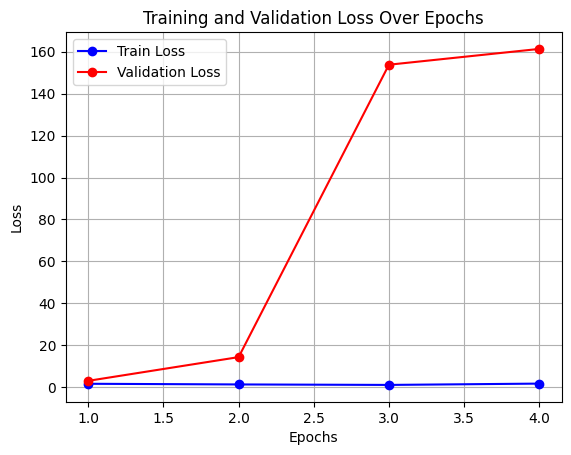

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt  # Import for plotting
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os

# Define paths
base_path = '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/'
train_dir = os.path.join(base_path, 'classification_dataset', 'train')
valid_dir = os.path.join(base_path, 'classification_dataset', 'valid')
test_dir = os.path.join(base_path, 'classification_dataset', 'test')

# Define image transformations with data augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resizing images to the required input size
    transforms.RandomHorizontalFlip(),  # Randomly flip images horizontally
    transforms.RandomRotation(15),  # Randomly rotate images by 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Random color jitter
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize for pretrained models
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load the pretrained ResNet50 model
model = models.resnet50(pretrained=True)

# Modify the final fully connected layer to match the number of classes (5 in this case)
num_classes = 5
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Add Dropout to the fully connected layer for regularization
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),  # Dropout with 50% probability
    nn.Linear(model.fc.in_features, num_classes)
)

# Send model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Define loss function with weight decay (L2 Regularization)
weight_decay = 1e-5  # Small L2 regularization term
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

# Lists to track the loss at each epoch
train_losses = []
valid_losses = []

# Early stopping setup
patience = 3  # Number of epochs to wait for improvement in validation loss
best_val_loss = float('inf')
epochs_without_improvement = 0

# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_train_loss = 0.0
    correct = 0
    total = 0

    # Training phase
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # Zero the gradients

        # Forward pass
        outputs = model(inputs)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Calculate the number of correct predictions
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = correct / total * 100

    # Append the training loss to track
    train_losses.append(train_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # Validation phase
    model.eval()  # Set model to evaluation mode for validation
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(valid_loader)
    valid_losses.append(val_loss)

    print(f"Validation Loss after Epoch {epoch+1}: {val_loss:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0  # Reset the counter
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Early stopping triggered due to no improvement in validation loss.")
            break

# Plot the training and validation loss over epochs
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', linestyle='-', color='b', label='Train Loss')
plt.plot(range(1, len(valid_losses) + 1), valid_losses, marker='o', linestyle='-', color='r', label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


Epoch [1/10], Train Loss: 1.3558, Train Accuracy: 43.33%, Validation Loss: 8.9588
Epoch [2/10], Train Loss: 0.2860, Train Accuracy: 88.33%, Validation Loss: 37.9231
Epoch [3/10], Train Loss: 0.0882, Train Accuracy: 98.33%, Validation Loss: 98.8014
Epoch [4/10], Train Loss: 0.2877, Train Accuracy: 95.00%, Validation Loss: 113.9169
Epoch [5/10], Train Loss: 0.0984, Train Accuracy: 98.33%, Validation Loss: 84.2199
Epoch [6/10], Train Loss: 0.0389, Train Accuracy: 100.00%, Validation Loss: 71.3565
Epoch [7/10], Train Loss: 0.0194, Train Accuracy: 100.00%, Validation Loss: 43.2762
Epoch [8/10], Train Loss: 0.0168, Train Accuracy: 100.00%, Validation Loss: 30.9466
Epoch [9/10], Train Loss: 0.0079, Train Accuracy: 100.00%, Validation Loss: 20.1591
Epoch [10/10], Train Loss: 0.0022, Train Accuracy: 100.00%, Validation Loss: 14.3010


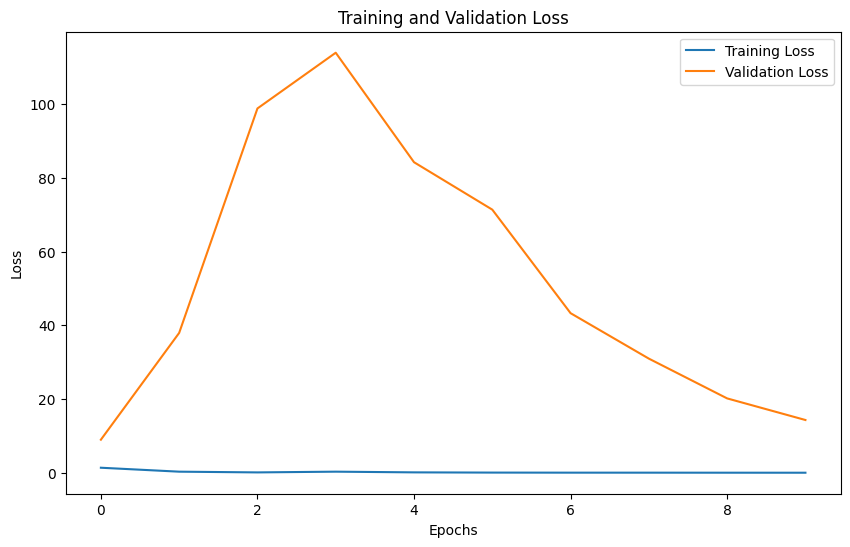

Test Loss: 14.6469
Test Accuracy: 26.67%
Test Precision: 0.68
Test Recall: 0.27
Test F1 Score: 0.17


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt  # Import for plotting
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os

# Define paths
base_path = '/content/drive/MyDrive/Deep_Learning_Wheat_Project.v2i.yolov8/'
train_dir = os.path.join(base_path, 'classification_dataset', 'train')
valid_dir = os.path.join(base_path, 'classification_dataset', 'valid')
test_dir = os.path.join(base_path, 'classification_dataset', 'test')

# Define image transformations for data augmentation and normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resizing images to the required input size
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize for pretrained models
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load the pretrained ResNet50 model
model = models.resnet50(pretrained=True)

# Modify the final fully connected layer to match the number of classes (5 in this case)
num_classes = 5
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Send model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

import matplotlib.pyplot as plt

# Lists to store training and validation losses
train_losses = []
valid_losses = []

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # Zero the gradients

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Calculate the number of correct predictions
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        running_loss += loss.item()

    # Calculate epoch training loss and accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total * 100
    train_losses.append(epoch_loss)

    # Validation loss calculation
    model.eval()  # Set the model to evaluation mode
    valid_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            valid_running_loss += loss.item()

    valid_epoch_loss = valid_running_loss / len(valid_loader)
    valid_losses.append(valid_epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.2f}%, "
          f"Validation Loss: {valid_epoch_loss:.4f}")

# Plot training and validation losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

def calculate_test_loss_and_metrics(loader):
    test_running_loss = 0.0
    labels_list = []
    preds_list = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Ensure device match
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            labels_list.extend(labels.cpu().numpy())  # Append ground truth labels
            preds_list.extend(predicted.cpu().numpy())  # Append predicted labels

    test_loss = test_running_loss / len(loader) if len(loader) > 0 else float('inf')
    accuracy = accuracy_score(labels_list, preds_list) if labels_list else 0.0
    precision = precision_score(labels_list, preds_list, average='weighted', zero_division=1)
    recall = recall_score(labels_list, preds_list, average='weighted', zero_division=1)
    f1 = f1_score(labels_list, preds_list, average='weighted', zero_division=1)

    return test_loss, accuracy, precision, recall, f1


# Evaluate the model on the test dataset
test_loss, test_accuracy, test_precision, test_recall, test_f1 = calculate_test_loss_and_metrics(test_loader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Precision: {test_precision:.2f}")
print(f"Test Recall: {test_recall:.2f}")
print(f"Test F1 Score: {test_f1:.2f}")


In [ ]:

from sklearn.metrics import classification_report

def class_wise_metrics(loader, valid_classes):
    labels_list = []
    preds_list = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            labels_list.extend(labels.cpu().numpy())
            preds_list.extend(predicted.cpu().numpy())

    # Convert valid_classes to a list of strings
    valid_classes_str = [str(cls) for cls in valid_classes]

    # Generate a classification report using the list of strings
    report = classification_report(labels_list, preds_list, target_names=valid_classes_str, zero_division=1)
    print(report)

class_wise_metrics(test_loader, valid_classes)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00         5
           1       1.00      0.00      0.00         8
           2       0.00      0.00      0.00         5
           3       1.00      0.33      0.50         6
           4       0.22      1.00      0.36         6

    accuracy                           0.27        30
   macro avg       0.64      0.27      0.17        30
weighted avg       0.68      0.27      0.17        30

